In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score 

In [2]:
dior = pd.read_csv("dior_clean.csv")
dior = dior[dior["product_subcategory_Bags & SLG"] == True] #I only select the category of accessories; I get rid of columns that became useless
dior = dior.drop(columns=[c for c in dior.columns if c.startswith("product_subcategory_")])
dior = dior.loc[:, dior.nunique() > 1]
dior.corr(numeric_only=True)["is_return"].sort_values(ascending=False) 
#If there is an irrealistic correlation, it would indicate some dataleakage (That is why I got rid off timespan_days_less_than_10)

is_return                      1.000000
quantity_0.0                   0.167275
sales_band_2000_4000           0.073194
sales_band_4000_6000           0.048062
shipping address - state_WY    0.025384
                                 ...   
csc commercial gestures       -0.077436
sales_band_0_500              -0.084429
quantity_1.0                  -0.130410
is_ltsourcing                 -0.161966
timespan_days_less_than_10    -0.986171
Name: is_return, Length: 90, dtype: float64

In [3]:
#We prepare the data (getting rid of dangerous correlations), split it into train and test and prepare the cross validation
X, y = dior.drop(columns=["order number", "order status", "is_return", "timespan_days_less_than_10", "shipping address - gender_miss", "shipping address - state_WY", "sales type_STW", "quantity_0.0"]), dior["is_return"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                            shuffle=True, random_state=72)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=72)

In [4]:
#Let us see the repartition of the two classes
display(  round( y_train.value_counts()/y_train.shape[0], 3   ))

is_return
0    0.726
1    0.274
Name: count, dtype: float64

In [5]:
#Test 1: Use Naive Bayes
nbc = GaussianNB()

nbc.fit(X_train, y_train)

y_pred_train_bayes = nbc.predict(X_train)
y_pred_test_bayes = nbc.predict(X_test)
p_nbc_test = nbc.predict_proba(X_test)[:, 1]

print(f"F1-score test Bayes: {f1_score(y_test, y_pred_test_bayes):.3f}")
print(f"F1-score train Bayes: {f1_score(y_train, y_pred_train_bayes):.3f}")

F1-score test Bayes: 0.463
F1-score train Bayes: 0.465


In [6]:
#Let's find the best threshold for F1-score
p_train = nbc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
best_t_Bayes_f1 = 0.5
best_f1 = 0

for t in thresholds:
    preds = (p_train >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t_Bayes_f1 = t

print(f"Best threshold {best_t_Bayes_f1:.3f}")
print(f"Best F1 {best_f1:.3f}")

y_pred_test_bayes_tunedf1 = (p_nbc_test >= best_t_Bayes_f1)

print(f"F1-score test Bayes with tuned threshold {f1_score(y_test, y_pred_test_bayes_tunedf1):.3f}")

Best threshold 0.750
Best F1 0.465
F1-score test Bayes with tuned threshold 0.463


In [7]:
#Test 2: Use Classifier which always predicts the most common class

# What is the most common class?
display(  round( y_train.value_counts()/y_train.shape[0], 3   ))

# So we predict always zero for the "most-common" classifier
y_pred_train_mc = np.zeros(len(y_train))
y_pred_test_mc = np.zeros(len(y_test))

print(f"F1-score test Most Common: {f1_score(y_test, y_pred_test_mc):.3f}")
print(f"F1-score train Most Common: {f1_score(y_train, y_pred_train_mc):.3f}")

is_return
0    0.726
1    0.274
Name: count, dtype: float64

F1-score test Most Common: 0.000
F1-score train Most Common: 0.000


In [8]:
#Test 3: Use Logistic Regression
# Here the model tries to minimize the log-loss function using gradient descent; 
# that is why we have to decide how many iterations we want
lrc = LogisticRegression(max_iter=5000, penalty = None)

lrc.fit(X_train, y_train)

y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_lrc = lrc.predict(X_test)
p_lrc_test = lrc.predict_proba(X_test)[:, 1]

print(f"F1-score test Logreg: {f1_score(y_test, y_pred_test_lrc):.3f}")
print(f"F1-score train Logreg: {f1_score(y_train, y_pred_train_lrc):.3f}")

F1-score test Logreg: 0.097
F1-score train Logreg: 0.098


In [9]:
#Adaptation threshold for f1-score
dior["is_return"].value_counts()

p_train = lrc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_f1 = 0.5
best_f1 = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred_train_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_f1 = t

print(f"Best f1: {best_f1:.3f}")
print(f"Best Threshold: {best_threshold_lrc_f1:.3f}")

p_test = lrc.predict_proba(X_test)[:, 1]
y_pred_lrcf1_test_best_thresh = (p_test >= best_threshold_lrc_f1).astype(int)
print(f"F1-score test Logreg with tuned threshold {f1_score(y_test, y_pred_lrcf1_test_best_thresh):.3f}")

Best f1: 0.488
Best Threshold: 0.220
F1-score test Logreg with tuned threshold 0.478


In [10]:
#Test 4: Use Logistic Regression with Lasso penalization as we could notice some overfitting in the logistic regression
lrc_lasso = LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=72)

lrc_lasso.fit(X_train, y_train)

y_pred_train_lrc_lasso = lrc_lasso.predict(X_train)
y_pred_test_lrc_lasso = lrc_lasso.predict(X_test)
p_lrc_lasso_test = lrc_lasso.predict_proba(X_test)[:, 1]


print(f"F1-score test Logreg (lasso): {f1_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"F1-score train Logreg (lasso): {f1_score(y_train, y_pred_train_lrc_lasso):.3f}")

F1-score test Logreg (lasso): 0.092
F1-score train Logreg (lasso): 0.092


In [11]:
#Threshold for f1-score
dior["is_return"].value_counts()

p_train = lrc_lasso.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_lasso_f1 = 0.5
best_f1 = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred_train_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_lasso_f1 = t

print(f"Best f1: {best_f1:.3f}")
print(f"Best Threshold: {best_threshold_lrc_lasso_f1:.3f}")

p_test = lrc_lasso.predict_proba(X_test)[:, 1]
y_pred_lrcf1_lasso_test_best_thresh = (p_test >= best_threshold_lrc_lasso_f1).astype(int)
print(f"F1-score test Logreg (lasso) with tuned threshold {f1_score(y_test, y_pred_lrcf1_lasso_test_best_thresh):.3f}")

Best f1: 0.488
Best Threshold: 0.240
F1-score test Logreg (lasso) with tuned threshold 0.478


In [12]:
#Test 5: Use Logistic Regression with Ridge penalization to see if it works better than Lasso
lrc_ridge = LogisticRegression(penalty="l2", max_iter=5000)

lrc_ridge.fit(X_train, y_train)

y_pred_train_lrc_ridge = lrc_ridge.predict(X_train)
y_pred_test_lrc_ridge = lrc_ridge.predict(X_test)
p_lrc_ridge_test = lrc_ridge.predict_proba(X_test)[:, 1]

print(f"F1-score test Logreg (ridge): {f1_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"F1-score train Logreg (ridge): {f1_score(y_train, y_pred_train_lrc_ridge):.3f}")

F1-score test Logreg (ridge): 0.092
F1-score train Logreg (ridge): 0.091


In [13]:
# Threshold for f1-score
dior["is_return"].value_counts()

p_train = lrc_ridge.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold_lrc_ridge_f1 = 0.5
best_f1 = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred_train_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_ridge_f1 = t

print(f"Best f1: {best_f1:.3f}")
print(f"Best Threshold: {best_threshold_lrc_ridge_f1:.3f}")

p_test = lrc_ridge.predict_proba(X_test)[:, 1]
y_pred_lrcf1_ridge_test_best_thresh = (p_test >= best_threshold_lrc_ridge_f1).astype(int)
print(f"F1-score test Logreg (Ridge) with tuned threshold {f1_score(y_test, y_pred_lrcf1_ridge_test_best_thresh):.3f}")

Best f1: 0.489
Best Threshold: 0.240
F1-score test Logreg (Ridge) with tuned threshold 0.480


In [14]:
#Test 6: Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score 


rf = RandomForestClassifier(n_estimators=300, #number of trees 
                            max_depth=20,
                            min_samples_split=2, 
                            min_samples_leaf=1, 
                            random_state=72 ) # to ensure reproducibility because of the bootstrap sampling
rf.fit(X_train, y_train) 

y_pred_test_rf = rf.predict(X_test) 
y_pred_train_rf = rf.predict(X_train)
p_rf_test = rf.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, y_pred_train_rf)
test_f1 = f1_score(y_test, y_pred_test_rf)



print(f"F1-score train Random Forest: {train_f1:.5f}")
print(f"F1-score test Random Forest: {test_f1:.5f}")

F1-score train Random Forest: 0.20239
F1-score test Random Forest: 0.13633


In [15]:
#Hyperparameter tuning (Threshold included) for f1-score

from sklearn.base import BaseEstimator, ClassifierMixin

class RFWithThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 n_estimators=100,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features="sqrt",
                 threshold=0.5,
                 random_state=72):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.threshold = threshold
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features,
            random_state=self.random_state,
        )
        self.model_.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)



param_distributions = {
    "n_estimators": [150, 300],
    "min_samples_split": [2, 3],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt"],
    "threshold": np.linspace(0.1, 0.9, 17),  
}


searchf1 = RandomizedSearchCV(
    estimator=RFWithThreshold(random_state=72),
    param_distributions=param_distributions,
    scoring="f1",
    cv=cv,
    refit=True,
    return_train_score=True,
    random_state=72,
)


searchf1.fit(X_train, y_train)


print(f"Best hyperparamters found : {searchf1.best_params_}")
print(f"Threshold found :{searchf1.best_params_["threshold"]:.3f}")


y_pred_train_tunedf1_rf = searchf1.predict(X_train)
y_pred_test_tunedf1_rf = searchf1.predict(X_test)
p_test_tunedf1_rf = searchf1.predict_proba(X_test)[:, 1]

print(f"F1-score train of Random Forest Tuned : {f1_score(y_train, y_pred_train_tunedf1_rf):.5f}")
print(f"F1-score test  of Random Forest Tuned : {f1_score(y_test, y_pred_test_tunedf1_rf):.5f}")



Best hyperparamters found : {'threshold': np.float64(0.2), 'n_estimators': 150, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Threshold found :0.200
F1-score train of Random Forest Tuned : 0.47316
F1-score test  of Random Forest Tuned : 0.46519


In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_leaf_nodes=30,#maximum number of leaves
    min_samples_leaf=20,#minimum number of observations in a leaf
    early_stopping=True,
    n_iter_no_change=20,#to decide the early stopping
    validation_fraction=0.2,#to decide the early stopping
    random_state=72)#to ensure reproducibility
gb.fit(X_train, y_train)
y_pred_test_boosting = gb.predict(X_test)
y_pred_train_boosting = gb.predict(X_train)
p_boosting_test = gb.predict_proba(X_test)[:, 1]

print(f"F1-score test Boosting: {f1_score(y_test, y_pred_test_boosting):.3f}")
print(f"F1-score train Boosting: {f1_score(y_train, y_pred_train_boosting):.3f}")

F1-score test Boosting: 0.127
F1-score train Boosting: 0.142


In [17]:
#Hyperparamter tuning (threshold included) for f1-score

param_dist = {
    "learning_rate": [0.05, 0.5],
    "max_leaf_nodes": [20, 30, 35],
    "min_samples_leaf": [10, 20]
}

search_boosting = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=True,
        n_iter_no_change=20,
        validation_fraction=0.2,
        random_state=72
    ),
    param_distributions=param_dist,              
    scoring="f1",
    cv=cv,
    random_state=72
)
search_boosting.fit(X_train, y_train)

best_model_boosting = search_boosting.best_estimator_

#This time we do not tune the threshold as a hyperparemeter but after the tuning of the hyperparameters using TunedThresholdClassifierCV
from sklearn.model_selection import TunedThresholdClassifierCV

boosting_tuned_f1 = TunedThresholdClassifierCV(
    estimator=best_model_boosting,
    scoring="f1",   
    cv=cv,
    refit=True
)

boosting_tuned_f1.fit(X_train, y_train)


y_pred_test_boostingf1_hyp  = boosting_tuned_f1.predict(X_test)
y_pred_train_boostingf1_hyp = boosting_tuned_f1.predict(X_train)
p_boosting_hypf1_test       = boosting_tuned_f1.predict_proba(X_test)[:, 1]

print(f"F1-score test Boosting with tuned hyperparameters: {f1_score(y_test, y_pred_test_boostingf1_hyp):.3f}")
print(f"F1-score train Boosting with tuned hyperparameters: {f1_score(y_train, y_pred_train_boostingf1_hyp):.3f}")


print(f"Best threshold selected by TunedThresholdClassifierCV: {boosting_tuned_f1.best_threshold_:.3f}")


F1-score test Boosting with tuned hyperparameters: 0.479
F1-score train Boosting with tuned hyperparameters: 0.510
Best threshold selected by TunedThresholdClassifierCV: 0.182


In [ ]:
#Test 8: Neural Network
from sklearn.neural_network import MLPClassifier
nnet = MLPClassifier(hidden_layer_sizes=(8, 16, 8),
                     learning_rate_init=0.003,#the size of the step in the stochastic gradient descent
                     activation="relu",#let us use the relu function as an activation function
                     solver="sgd", # We choose as a solver the stochastic gradient deschent
                     alpha=0.001,#ridge penalty
                     batch_size=32, #necessary if we make a stochastic gradient descent
                     max_iter=500,
                     early_stopping=True,
                     n_iter_no_change=20,#number of iterations util it stops (PLOT THE LOSS) PATIENCE PARAMETER (TWO HOURS LIMIT)
                     random_state = 72)
nnet.fit(X_train, y_train)

y_pred_train_neuron = nnet.predict(X_train)
y_pred_test_neuron = nnet.predict(X_test)

print(f"F1 test Neural Network: {f1_score(y_test, y_pred_test_neuron):.3f}")
print(f"F1 train Neural Network: {f1_score(y_train, y_pred_train_neuron):.3f}")

F1 test Neural Network: 0.114
F1 train Neural Network: 0.109


In [19]:
#Hyperparamter tuning (threshold included) for f1-score
param_dist = {
    "hidden_layer_sizes": [(16,), (16, 16), (8, 16, 8), (16, 16, 16)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.003, 0.008],
    "solver": ["adam", "sgd"]
}

search_neuron = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=20, batch_size=32, activation="relu", random_state = 72),
    param_distributions=param_dist,
    scoring="f1",#that is what we want to minimize
    cv=cv, random_state = 72# to ensure reproducibilty without this different folds for the cv will be used each time
)
search_neuron.fit(X_train, y_train)
best_model_neuron = search_neuron.best_estimator_

#We use as before TunedThresholdClassifierCV

neuron_tuned_f1 = TunedThresholdClassifierCV(
    estimator=best_model_neuron,
    scoring="f1",
    cv=cv,
    refit=True
)

neuron_tuned_f1.fit(X_train, y_train)


y_pred_test_neuronf1_hyp  = neuron_tuned_f1.predict(X_test)
y_pred_train_neuronf1_hyp = neuron_tuned_f1.predict(X_train)
p_neuronf1_hyp_test       = neuron_tuned_f1.predict_proba(X_test)[:, 1]

print(f"F1-score test Neural Network with tuned hyperparameters: {f1_score(y_test, y_pred_test_neuronf1_hyp):.3f}")
print(f"F1-score train Neural Network with tuned hyperparameters: {f1_score(y_train, y_pred_train_neuronf1_hyp):.3f}")

print(f"Best threshold selected by TunedThresholdClassifierCV: {neuron_tuned_f1.best_threshold_:.3f}")


F1-score test Neural Network with tuned hyperparameters: 0.473
F1-score train Neural Network with tuned hyperparameters: 0.490
Best threshold selected by TunedThresholdClassifierCV: 0.202


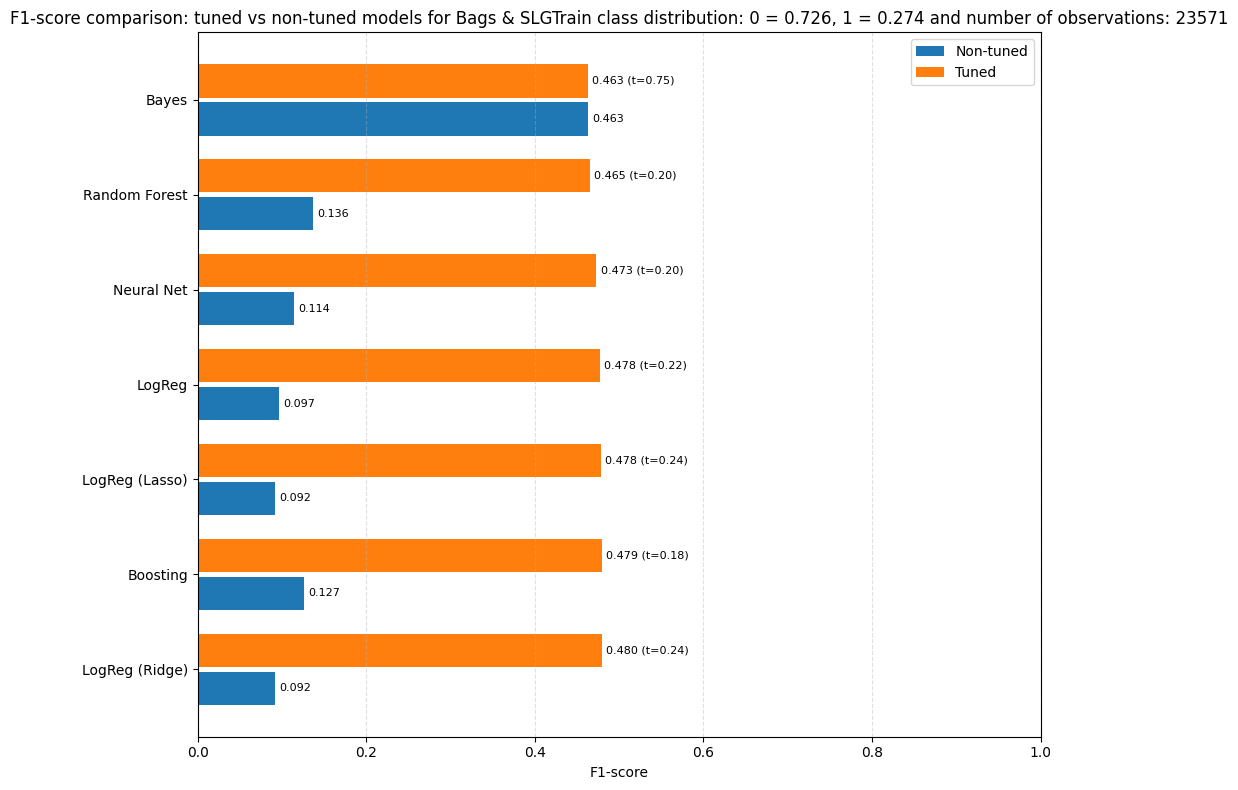

In [20]:
# F1-score measures: 2 · (Precision · Recall) / (Precision + Recall)
# Goal: find an equilibrium between Precision and Recall.

models = {
    "Bayes": (
        f1_score(y_test, y_pred_test_bayes),
        f1_score(y_test, y_pred_test_bayes_tunedf1),
        best_t_Bayes_f1
    ),
    "LogReg": (
        f1_score(y_test, y_pred_test_lrc),
        f1_score(y_test, y_pred_lrcf1_test_best_thresh),
        best_threshold_lrc_f1
    ),
    "LogReg (Lasso)": (
        f1_score(y_test, y_pred_test_lrc_lasso),
        f1_score(y_test, y_pred_lrcf1_lasso_test_best_thresh),
        best_threshold_lrc_lasso_f1
    ),
    "LogReg (Ridge)": (
        f1_score(y_test, y_pred_test_lrc_ridge),
        f1_score(y_test, y_pred_lrcf1_ridge_test_best_thresh),
        best_threshold_lrc_ridge_f1
    ),
    "Neural Net": (
        f1_score(y_test, y_pred_test_neuron),
        f1_score(y_test, y_pred_test_neuronf1_hyp),
        neuron_tuned_f1.best_threshold_
    ),
    "Random Forest": (
        f1_score(y_test, y_pred_test_rf),
        f1_score(y_test, y_pred_test_tunedf1_rf),
        searchf1.best_params_["threshold"]
    ),
    "Boosting": (
        f1_score(y_test, y_pred_test_boosting),
        f1_score(y_test, y_pred_test_boostingf1_hyp),
        boosting_tuned_f1.best_threshold_
    )
}


rows = []
for name, (f1_base, f1_tuned, t) in models.items():
    if f1_tuned is not None:
        max_f1 = max(f1_base, f1_tuned)
    else:
        max_f1 = f1_base
    rows.append([name, f1_base, f1_tuned, t, max_f1])

df_f1 = pd.DataFrame(rows, columns=["Model", "F1_base", "F1_tuned", "Threshold", "MaxF1"])
df_f1 = df_f1.sort_values("MaxF1", ascending=False).reset_index(drop=True)


class_ratio = y_train.value_counts(normalize=True).sort_index()
neg = class_ratio.iloc[0]
pos = class_ratio.iloc[1]


plt.figure(figsize=(10, 8))
y = np.arange(len(df_f1))

plt.barh(y - 0.2, df_f1["F1_base"], height=0.35, label="Non-tuned")
plt.barh(y + 0.2, df_f1["F1_tuned"], height=0.35, label="Tuned")


for i, row in df_f1.iterrows():
    
    plt.text(row["F1_base"] + 0.005, i - 0.2,
             f"{row["F1_base"]:.3f}", va="center", fontsize=8)
    
    if row["F1_tuned"] is not None:
        if row["Threshold"] is not None:
            txt = f"{row["F1_tuned"]:.3f} (t={row["Threshold"]:.2f})"
        else:
            txt = f"{row["F1_tuned"]:.3f}"
        plt.text(row["F1_tuned"] + 0.005, i + 0.2,
                 txt, va="center", fontsize=8)

plt.yticks(y, df_f1["Model"])
plt.xlabel("F1-score")
plt.title(
    "F1-score comparison: tuned vs non-tuned models for Bags & SLG"
    f"Train class distribution: 0 = {neg:.3f}, 1 = {pos:.3f} and number of observations: {y_train.shape[0]}"
)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

